# <font face = 'Spectral'> Step 2 of Project

<font size = 5.7><font face = 'Spectral'><font color = 'adeio'> The goal of Step 2 is to: 
1. <font face = 'Spectral'><font size = 4.7>Use curve_fit from scipy (or another fitting algorithm) in order to fit for, and divide out both the linear and oscillatory artifacts in the data. Do so while assuming the root mean squared experimental error on the flux measurements is 0.0003. 
2. <font face = 'Spectral'><font size = 4.7>Report the uncertainty in your best fit parameters, and graph both the model and the data on the same plot. Also plot what the data looks like after the artifacts have been removed.
3. <font face = 'Spectral'><font size = 4.7>Label each plot to provide clarity, and have the notebook save the figures as PDFs.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.table import Table

In [2]:
data = Table.read('Planet_Lightcurve.fits')
print(data.colnames)
print(data)

['time [days]', 'flux']
    time [days]             flux       
-------------------- ------------------
                -0.3 0.9718556446853187
 -0.2993993993993994  0.974430548606305
 -0.2987987987987988 0.9696244442016453
 -0.2981981981981982 0.9672472927361904
 -0.2975975975975976 0.9739989623419928
  -0.296996996996997 0.9689265223770298
-0.29639639639639637 0.9678268042192515
 -0.2957957957957958 0.9676453996308826
-0.29519519519519516 0.9703558446606856
 -0.2945945945945946 0.9738800653806102
                 ...                ...
  0.2945945945945945 0.9914653112446374
 0.29519519519519516 0.9978371225844164
  0.2957957957957958  1.000796759382211
  0.2963963963963964 0.9968976911446861
 0.29699699699699694 1.0017105738372651
  0.2975975975975976 1.0025198411286196
  0.2981981981981982 0.9930781407930032
 0.29879879879879884 0.9969834224859118
 0.29939939939939936 0.9998456765152839
                 0.3 0.9997001308741668
Length = 1000 rows


In [3]:
flux_raw = np.asarray(data['flux'])
time = np.asarray(data['time [days]'])

In [4]:
print(flux_raw, time)

[0.97185564 0.97443055 0.96962444 0.96724729 0.97399896 0.96892652
 0.9678268  0.9676454  0.97035584 0.97388007 0.97241663 0.97372433
 0.96797161 0.96827912 0.96886515 0.97021077 0.97376163 0.97407641
 0.96827531 0.9691821  0.97206701 0.97287964 0.97089238 0.9752087
 0.96900101 0.97139327 0.96912348 0.972703   0.97609685 0.97190061
 0.97183435 0.97153929 0.96938613 0.96807855 0.96788307 0.97083331
 0.97340795 0.96560773 0.96525122 0.9670121  0.97241345 0.97041527
 0.97649412 0.97250546 0.97003225 0.97015362 0.96963418 0.97571573
 0.97534068 0.97659574 0.97455864 0.97349602 0.97016717 0.97088355
 0.97138615 0.97028953 0.97620331 0.97926664 0.97335313 0.9717849
 0.97494361 0.97848401 0.97583284 0.97465771 0.97549294 0.97447484
 0.97679513 0.97051526 0.97209453 0.98005565 0.97521752 0.9743067
 0.97234711 0.97384729 0.97113639 0.97043614 0.97970447 0.97673673
 0.97046434 0.97360593 0.97339293 0.97637817 0.973334   0.97981656
 0.97543256 0.97558297 0.97638383 0.97609627 0.97602878 0.9759800

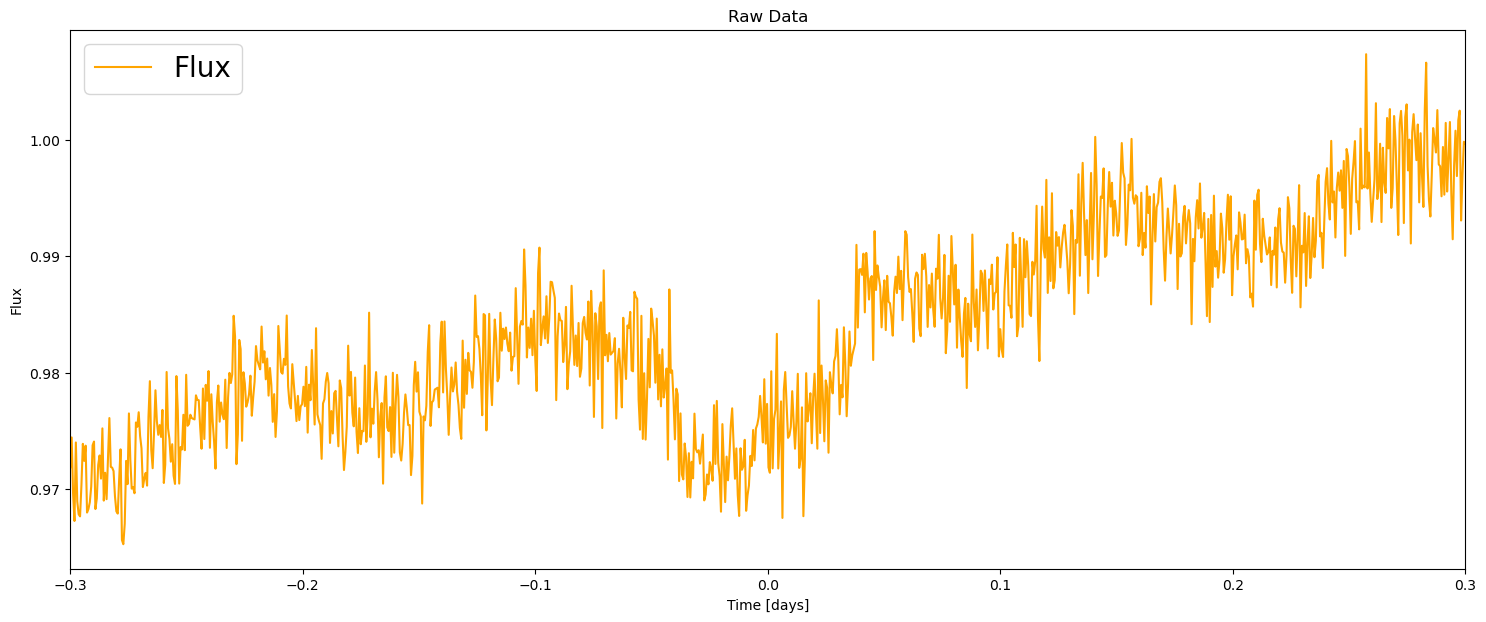

In [5]:
plt.figure(figsize=(18,7))

plt.plot(time, 
         flux_raw, 
         label='Flux', 
         c='orange', 
         linewidth=1.5, 
         linestyle='-'
        )
plt.xlabel('Time [days]'); plt.ylabel('Flux'); plt.title('Raw Data')
plt.xlim(-0.3, 0.3)
legend = plt.legend(loc='upper left', fontsize=20)

<font size = 5.3><font face = 'Spectral'><font color = 'adeio'> Optimization

In [7]:
# initial attempt at sorting that did not turn out right. Data was very loosely fit.
'''
# importing Lomb-Scargle to detect "impurities"
from astropy.timeseries import LombScargle

# estimating values
ls = LombScargle(time, flux_raw, normalization='standard')
frequency, power = ls.autopower(minimum_frequency=1, maximum_frequency=200)
freq0 = frequency[np.argmax(power)]
A0 = 0.003
print(f"A0 is equal to: {A0}")
# refining frequency estimate. previous was far too off
best_freq = frequency[np.argmax(power)]
best_period = 1 / best_freq  # in days
print(f"Peak frequency: {best_freq:.6f} cycles/day")
print(f"Corresponding period: {best_period:.4f} days")

dt = np.diff(time)
print(f"Median cadence: {np.median(dt):.6f} days")
print(f"Corresponding frequency: {1/np.median(dt):.2f} cycles/day")

mask = (frequency >= 1) & (frequency <= 50)  # periods between ~0.02 and 1 day
plt.plot(frequency[mask], power[mask])
plt.xlabel('Frequency [cycles/day]')
plt.show()
'''

'\n# importing Lomb-Scargle to detect "impurities"\nfrom astropy.timeseries import LombScargle\n\n# estimating values\nls = LombScargle(time, flux_raw, normalization=\'standard\')\nfrequency, power = ls.autopower(minimum_frequency=1, maximum_frequency=200)\nfreq0 = frequency[np.argmax(power)]\nA0 = 0.003\nprint(f"A0 is equal to: {A0}")\n# refining frequency estimate. previous was far too off\nbest_freq = frequency[np.argmax(power)]\nbest_period = 1 / best_freq  # in days\nprint(f"Peak frequency: {best_freq:.6f} cycles/day")\nprint(f"Corresponding period: {best_period:.4f} days")\n\ndt = np.diff(time)\nprint(f"Median cadence: {np.median(dt):.6f} days")\nprint(f"Corresponding frequency: {1/np.median(dt):.2f} cycles/day")\n\nmask = (frequency >= 1) & (frequency <= 50)  # periods between ~0.02 and 1 day\nplt.plot(frequency[mask], power[mask])\nplt.xlabel(\'Frequency [cycles/day]\')\nplt.show()\n'

In [21]:
# Initial Detrending Trial
'''
from astropy.timeseries import LombScargle
from scipy.optimize import curve_fit

# using transit masking to fix the linear trend first
transit_mask = np.abs(time) > 0.08
p_linear = np.polyfit(time[transit_mask], flux_raw[transit_mask], 1)
linear_trend = np.polyval(p_linear, time)

print(f"Linear fit: slope = {p_linear[0]:.5f}, intercept = {p_linear[1]:.5f}")

# dividing out the linear artifacts
flux_detrended = flux_raw / linear_trend

# running the lombscargle on the now detrended data.
## beforehand, I attempted to remove linear and oscillatory artifacts together. now, it is done separately.
ls = LombScargle(time, flux_detrended, normalization='standard')
frequency, power = ls.autopower(minimum_frequency=1, maximum_frequency=200)

freq0 = frequency[np.argmax(power)]
best_period = 1 / freq0
print(f"Peak frequency: {freq0:.4f} cycles/day")
print(f"Corresponding period: {best_period:.5f} days ({best_period*24*60:.2f} minutes)")

A0 = 0.004
print(f"A0 estimate: {A0:.5f}")

plt.figure(figsize=(12, 4))
plt.plot(frequency, power, c='green')
plt.xlabel('Frequency [cycles/day]'); plt.ylabel('LS Power'); plt.title('Lomb-Scargle Periodogram (detrended flux)')
plt.axvline(freq0, color='r', linestyle='--', label=f'Peak: {freq0:.1f} c/day')
plt.legend(); plt.show()
'''

'\nfrom astropy.timeseries import LombScargle\nfrom scipy.optimize import curve_fit\n\n# using transit masking to fix the linear trend first\ntransit_mask = np.abs(time) > 0.08\np_linear = np.polyfit(time[transit_mask], flux_raw[transit_mask], 1)\nlinear_trend = np.polyval(p_linear, time)\n\nprint(f"Linear fit: slope = {p_linear[0]:.5f}, intercept = {p_linear[1]:.5f}")\n\n# dividing out the linear artifacts\nflux_detrended = flux_raw / linear_trend\n\n# running the lombscargle on the now detrended data.\n## beforehand, I attempted to remove linear and oscillatory artifacts together. now, it is done separately.\nls = LombScargle(time, flux_detrended, normalization=\'standard\')\nfrequency, power = ls.autopower(minimum_frequency=1, maximum_frequency=200)\n\nfreq0 = frequency[np.argmax(power)]\nbest_period = 1 / freq0\nprint(f"Peak frequency: {freq0:.4f} cycles/day")\nprint(f"Corresponding period: {best_period:.5f} days ({best_period*24*60:.2f} minutes)")\n\nA0 = 0.004\nprint(f"A0 estimat

In [22]:
# initial attempt in conjunction with the prior 'initial attempt' where linear & oscillatory artifacts were-
# being sorted out in tandem.
'''
from scipy.optimize import curve_fit

# employing curve_fit to calculate an optimized dataset
popt, pcov = curve_fit(optimize_model,
                       time,
                       flux_raw,
                       sigma=np.full(len(flux_raw), 0.0003),
                       absolute_sigma=True,
                       p0=[.5, 0.97, A0, freq0, 0]
                      )

print(popt)
'''

'\nfrom scipy.optimize import curve_fit\n\n# employing curve_fit to calculate an optimized dataset\npopt, pcov = curve_fit(optimize_model,\n                       time,\n                       flux_raw,\n                       sigma=np.full(len(flux_raw), 0.0003),\n                       absolute_sigma=True,\n                       p0=[.5, 0.97, A0, freq0, 0]\n                      )\n\nprint(popt)\n'

In [23]:
# an additional failed cleaning attempt
'''
# new analysis/fit — mask transit so curve_fit only sees the artifact signal
transit_mask = np.abs(time) > 0.08   # same mask used for linear detrending

f0 = p_linear[0] # slope from linear fit
b0 = p_linear[1] # intercept from linear fit

popt, pcov = curve_fit(optimize_model,
                       time[transit_mask],
                       flux_raw[transit_mask],
                       sigma=np.full(transit_mask.sum(), 0.0003),
                       absolute_sigma=True,
                       p0=[f0, b0, A0, freq0, 0],
                       bounds=([-1,0.90, 0, freq0*0.5, -np.pi],[ 1,   1.10, 0.05, freq0*2.0,  np.pi]),
                       maxfev=10000
                      )

perr = np.sqrt(np.diag(pcov))
labels = ['f (slope)', 'b (intercept)', 'A (amplitude)', 'freq', 'phi']
print("Best-fit parameters:")
for label, val, err in zip(labels, popt, perr):
    print(f"  {label:15s} = {val:.6f} ± {err:.6f}")
'''

'\n# new analysis/fit — mask transit so curve_fit only sees the artifact signal\ntransit_mask = np.abs(time) > 0.08   # same mask used for linear detrending\n\nf0 = p_linear[0] # slope from linear fit\nb0 = p_linear[1] # intercept from linear fit\n\npopt, pcov = curve_fit(optimize_model,\n                       time[transit_mask],\n                       flux_raw[transit_mask],\n                       sigma=np.full(transit_mask.sum(), 0.0003),\n                       absolute_sigma=True,\n                       p0=[f0, b0, A0, freq0, 0],\n                       bounds=([-1,0.90, 0, freq0*0.5, -np.pi],[ 1,   1.10, 0.05, freq0*2.0,  np.pi]),\n                       maxfev=10000\n                      )\n\nperr = np.sqrt(np.diag(pcov))\nlabels = [\'f (slope)\', \'b (intercept)\', \'A (amplitude)\', \'freq\', \'phi\']\nprint("Best-fit parameters:")\nfor label, val, err in zip(labels, popt, perr):\n    print(f"  {label:15s} = {val:.6f} ± {err:.6f}")\n'

In [24]:
# ""
'''
flux_clean = flux_raw / optimize_model(time, *popt)

plt.figure(figsize=(8,7))
plt.plot(time, flux_raw, label='raw')
plt.plot(time, optimize_model(time, *popt), label='artifact model')

plt.xlabel('Time [days]'); plt.ylabel('Flux'); plt.title('Artifact fit')
plt.legend()
plt.show()

# Check the cleaned flux
plt.figure(figsize=(16,7))
plt.plot(time, flux_clean, label='cleaned')

plt.xlabel('Time [days]'); plt.ylabel('Flux (cleaned)')
plt.title('Cleaned flux')
plt.legend()
plt.show()
'''

"\nflux_clean = flux_raw / optimize_model(time, *popt)\n\nplt.figure(figsize=(8,7))\nplt.plot(time, flux_raw, label='raw')\nplt.plot(time, optimize_model(time, *popt), label='artifact model')\n\nplt.xlabel('Time [days]'); plt.ylabel('Flux'); plt.title('Artifact fit')\nplt.legend()\nplt.show()\n\n# Check the cleaned flux\nplt.figure(figsize=(16,7))\nplt.plot(time, flux_clean, label='cleaned')\n\nplt.xlabel('Time [days]'); plt.ylabel('Flux (cleaned)')\nplt.title('Cleaned flux')\nplt.legend()\nplt.show()\n"

<font size = 5.7><font face = 'Spectral'><font color = 'adeio'>Congregated Operations

LS peak frequency : 8.0000 cycles/day
Corresponding period: 0.12500 days (180.00 min)


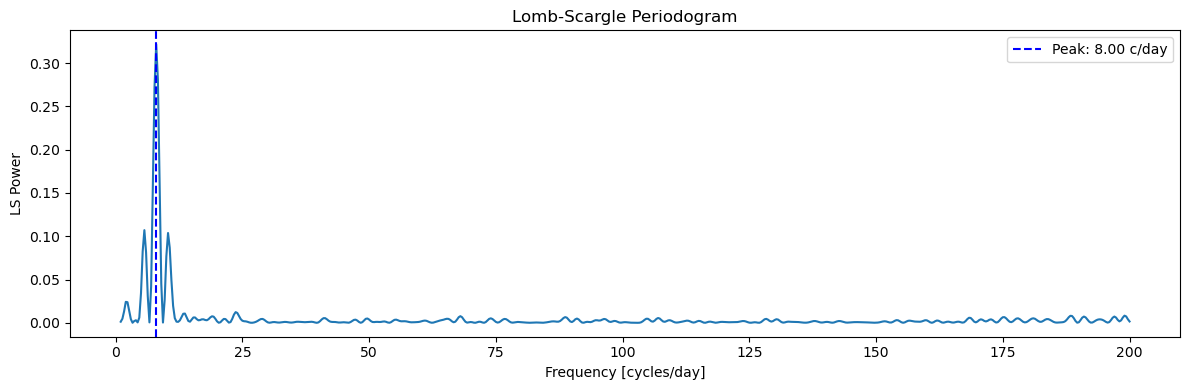


Best-fit parameters (1-sigma uncertainties):
slope (f) = 0.03916  ±  0.00006
intercept(b) = 0.98501  ±  0.00001
amplitude(A) = 0.00288  ±  0.00002
frequency = 8.0401  ±  0.0046 c/day
phase (phi) = 0.2702  ±  0.0058 rad


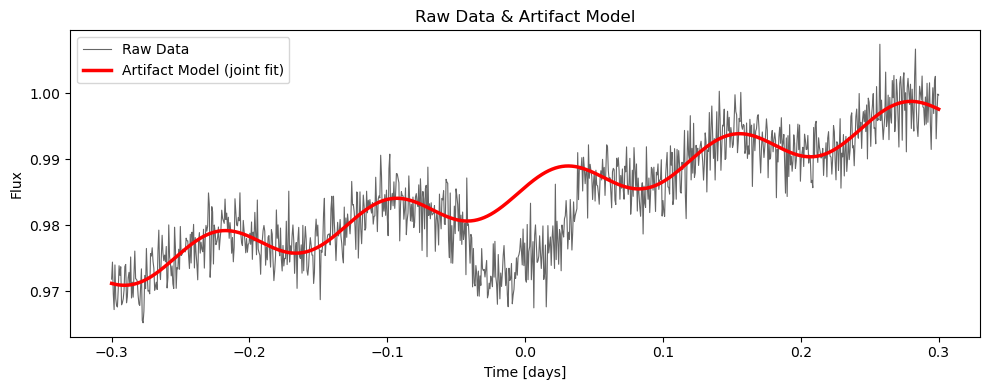

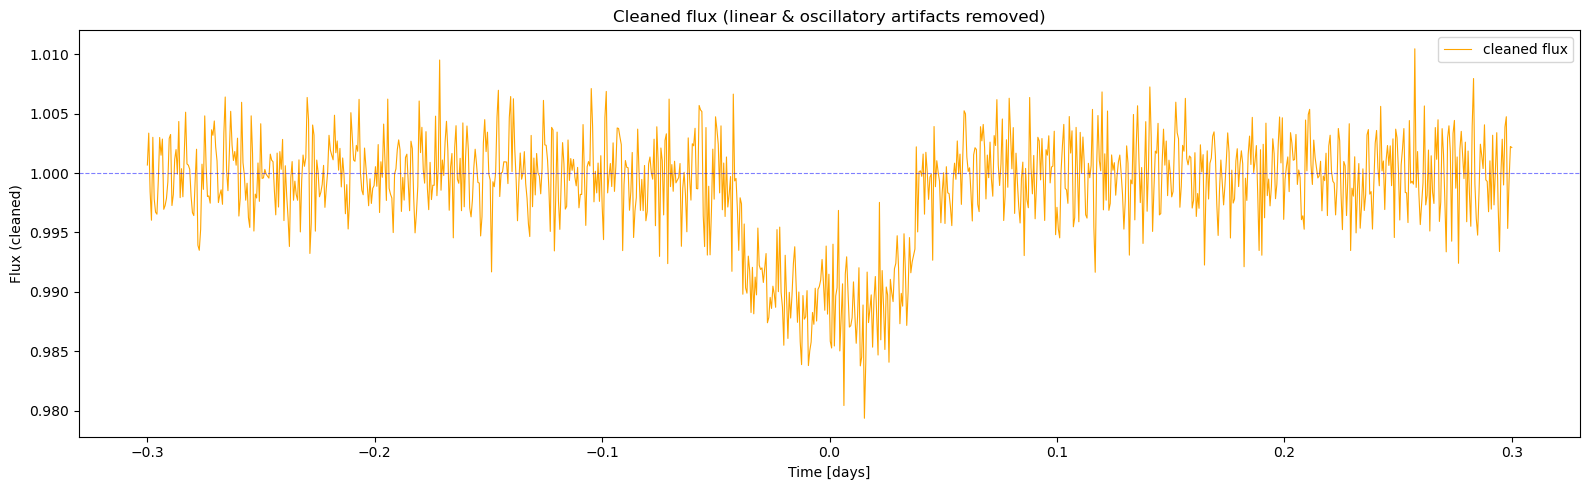

In [26]:
from astropy.timeseries import LombScargle
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

sigma_raw = 0.0003
transit_mask = np.abs(time) > 0.08

# numpy function 'polyfit' used to find initial guesses
p_linear = np.polyfit(time[transit_mask], flux_raw[transit_mask], 1)
f0, b0 = p_linear  # slope and intercept starting guesses
linear_trend = np.polyval(p_linear, time)

# detrending rist
flux_detrended = flux_raw / linear_trend
ls = LombScargle(time[transit_mask], flux_detrended[transit_mask], normalization='standard')
frequency, power = ls.autopower(minimum_frequency=1, maximum_frequency=200)
freq0 = frequency[np.argmax(power)]

best_period = 1 / freq0
print(f"LS peak frequency : {freq0:.4f} cycles/day")
print(f"Corresponding period: {best_period:.5f} days ({best_period*24*60:.2f} min)")

plt.figure(figsize=(12, 4))
plt.plot(frequency, power)
plt.axvline(freq0, color='blue', ls='--', label=f'Peak: {freq0:.2f} c/day')
plt.xlabel('Frequency [cycles/day]'); plt.ylabel('LS Power')
plt.title('Lomb-Scargle Periodogram')
plt.legend(); plt.tight_layout()
plt.savefig('lomb_scargle.pdf', bbox_inches='tight')
plt.show()

# joining curve fit and optimize model
def optimize_model(t, f, b, A, freq, phi):
    linear      = t * f + b
    oscillatory = 1 + A * np.sin(2 * np.pi * freq * t + phi)
    return linear * oscillatory

sigma_arr = np.full(transit_mask.sum(), sigma_raw)

popt, pcov = curve_fit(optimize_model,
                       time[transit_mask],
                       flux_raw[transit_mask],
                       p0 = [f0, b0, 0.004, freq0, 0.0], sigma = sigma_arr,
                       absolute_sigma = True,
                       bounds = ([-2,   0.85,  0,      freq0 * 0.5, -np.pi],
                                 [ 2,   1.15,  0.05,   freq0 * 2.0,  np.pi]),
                       maxfev = 50000
                      )

perr = np.sqrt(np.diag(pcov))
f_fit, b_fit, A_fit, freq_fit, phi_fit = popt
f_err, b_err, A_err, freq_err, phi_err = perr

print("\nBest-fit parameters (1-sigma uncertainties):")
print(f"slope (f) = {f_fit:.5f}  ±  {f_err:.5f}")
print(f"intercept(b) = {b_fit:.5f}  ±  {b_err:.5f}")
print(f"amplitude(A) = {A_fit:.5f}  ±  {A_err:.5f}")
print(f"frequency = {freq_fit:.4f}  ±  {freq_err:.4f} c/day")
print(f"phase (phi) = {phi_fit:.4f}  ±  {phi_err:.4f} rad")

# building the artifact model and plotting plots
artifact_model = optimize_model(time, *popt)
flux_clean     = flux_raw / artifact_model

plt.figure(figsize=(10, 4))
plt.plot(time, flux_raw,      'k',  lw=0.8, alpha=0.6, label='Raw Data')
plt.plot(time, artifact_model,'r',  lw=2.5, label='Artifact Model (joint fit)')
plt.xlabel('Time [days]'); plt.ylabel('Flux')
plt.title('Raw Data & Artifact Model')
plt.legend(); plt.tight_layout()
plt.savefig('artifact_fit.pdf', bbox_inches='tight')
plt.show()

plt.figure(figsize=(16, 5))
plt.plot(time, flux_clean, 'orange', lw=0.8, label='cleaned flux')
plt.axhline(1.0, color='blue', lw=0.8, ls='--', alpha=0.5)
plt.xlabel('Time [days]'); plt.ylabel('Flux (cleaned)')
plt.title('Cleaned flux (linear & oscillatory artifacts removed)')
plt.legend(); plt.tight_layout()
plt.savefig('cleaned_flux.pdf', bbox_inches='tight'); plt.show()